In [69]:
import numpy as np
import matplotlib.pyplot as plt
from mpdaf.obj import Cube
from astropy.coordinates import SkyCoord
import sys
import os
import plotfancy as pf
from matplotlib.patches import Circle, ConnectionPatch, FancyArrowPatch, Arrow
from astropy.visualization import ZScaleInterval
import seaborn as sns

import seaborn as sns

from types import SimpleNamespace
import re
from astropy.io import ascii, fits
from astropy import units as u
from astropy.constants import c as speedoflight
from astropy.table import Table, vstack, hstack, join, Column
from scipy.optimize import curve_fit, root
from astropy.cosmology import Planck18 as cosmo
from astropy import coordinates as coords
from astroquery.sdss import SDSS
from requests.exceptions import ConnectionError
from matplotlib.lines import Line2D
# from hst_phot import *
from prospect.models.templates import TemplateLibrary
from prospect.models import SpecModel
import prospect.fitting as fitting
from prospect.io import write_results as writer
import prospect.io.read_results as reader
from prospect.sources import CSPSpecBasis
from prospect.models import priors
from genesis_metallicity.genesis_metallicity import genesis_metallicity
from mpl_toolkits.axes_grid1.inset_locator import mark_inset, zoomed_inset_axes
from tqdm import tqdm

# from calculate_jiang19_metallicity import calculate_metallicity_jiang19 as cjm19
sys.path.append('../../../')
import src.ifu_tools.line_ratios as lr
import src.ifu_tools.ifutools as ift

import logging 
logging.getLogger('mpdaf').setLevel(logging.WARNING)

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

In [140]:
selection = []
l = [50,100]
tabs = []

for i,f in enumerate(['','../week6-7/']):
    test = ascii.read(f+'allsources.csv')
    tab = test[test['object_id']!= 'STACK']
    tabs.append(tab)

    #### STATISTICAL FITTING CORRECTION
    ratio = tab['oiii5007_flux']/tab['oiii4959_flux']
    mask = np.isfinite(ratio)
    median = np.median(ratio[mask])
    tab['oiii4959_flux'] = tab['oiii4959_flux']*(median/3)

    SNR_mask = ((tab['oiii5007_flux']/tab['oiii5007_flux_err'])>5)&((tab['oiii4959_flux']/tab['oiii4959_flux_err'])>5)
    EW_mask = (tab['oiii5007_ew']>l[i])|(tab['hbeta_ew']>l[i]/2)
    selection0 = tab[SNR_mask&EW_mask].copy()
    selection.append(selection0)

In [87]:
len(selection[0])

35

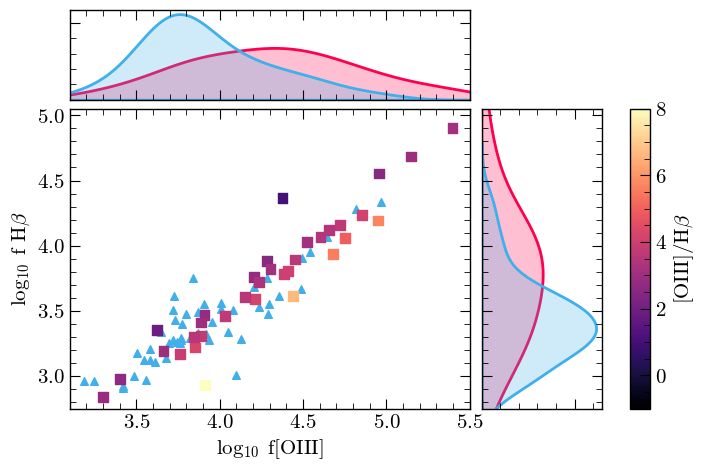

In [128]:
fig, ax = pf.create_plot()

ax.set_xlabel(r'$\log_{10}\;$f[OIII]')
ax.set_ylabel(r'$\log_{10}\;$f H$\beta$')

ax2 = fig.add_axes((0,1.03,1,0.3), sharex=ax)
ax3 = fig.add_axes((1.03,0,0.3,1), sharey=ax)

for a in [ax2,ax3]:
    plt.setp(a.get_xticklabels(), visible=False)
    plt.setp(a.get_yticklabels(), visible=False)
cbar = fig.add_axes((1.4,0,0.05,1))

axes = [ax,ax2,ax3,cbar]


m = ['s','^']
c = ['#ff004f',"#41afea"]
sz = [50,30]

for i,s in enumerate(selection):
    sc = ax.scatter(np.log10(s['oiii5007_flux']),np.log10(s['hbeta_flux']),
               marker = m[i], c=c[i] if i==1 else (s['oiii5007_flux']/s['hbeta_flux']),
               s=float(sz[i]), cmap='magma' if i==0 else None,
               vmax = 8 if i==0 else None,
               vmin = -1 if i==0 else None, zorder=-i)
    
    sns.kdeplot(x = np.log10(s['oiii5007_flux']), ax =ax2, color=c[i], lw=2, fill=True)
    sns.kdeplot(y = np.log10(s['hbeta_flux']), ax =ax3, color=c[i], lw=2, fill=True)
    
    
    if i ==0:
        plt.colorbar(sc, label=r'[OIII]/H$\beta$', cax=cbar)
    
ax.set_xlim(3.1,5.5)
ax.set_ylim(2.75,5.05)

pf.fix_plot(axes) 
fig.savefig(f'figs/oiihbeta.png', dpi=600, bbox_inches='tight')

In [98]:
mtable = []
for s in selection:
    s['Z_dir_gen'] = np.ones_like(s['z'])*1.031492
    s['Z_dir_gen_err'] = np.ones_like(s['z'])*1.031492
    s['direct'] = np.ones_like(s['z'])

    selection_mask = (s['hdelta_flux']>0)&(s['oii3726_flux']>0)&(s['oii3729_flux']>0)&(s['hgamma_flux']>0)&(s['hbeta_flux']>0)&(s['oiii5007_flux']>0)&(s['oiii4959_flux']>0)
    selection_new = s[selection_mask]
    i=0

    for p in selection_new:
        i+=1
        # print(i)
        input_dict = {}
        input_dict['redshift'] =  p['z']
        input_dict['OII']      = [p['oii3726_flux']+p['oii3729_flux'],np.sqrt(np.sum(np.array([p['oii3726_flux_err'],p['oii3729_flux_err']])**2))]
        input_dict['Hdelta']   = [p['hdelta_flux'], p['hdelta_flux_err']]
        input_dict['Hgamma']   = [p['hgamma_flux'], p['hgamma_flux_err']]
        input_dict['Hbeta']    = [p['hbeta_flux'], p['hbeta_flux_err']]
        input_dict['O4959']    = [p['oiii4959_flux'],p['oiii4959_flux_err']]
        input_dict['O5007']    = [p['oiii5007_flux'],p['oiii5007_flux_err']]
        input_dict['Hbeta_EW'] = [p['hbeta_ew'], p['hbeta_ew_err']]

        direct = 0
        # if p['oiii4363_flux']>0:
        #     input_dict['O4363'] = [p['oiii4363_flux'],p['oiii4363_flux_err']]
        #     direct = 1

        try:
            galaxy = genesis_metallicity(input_dict)
            p['Z_dir_gen'] = galaxy.metallicity.n
            p['Z_dir_gen_err'] = galaxy.metallicity.s
            p['direct'] = direct
        except:
            print('failed')
            p['Z_dir_gen'] = np.nan
            p['Z_dir_gen_err'] = np.nan
            p['direct'] = np.nan
    mtable.append(selection_new)


failed


In [113]:
sfrs = []
sfrs_er = []

for s in mtable:
    D_L = cosmo.luminosity_distance(s['z'])
    D_L_cm = D_L.to(u.cm).value
    L_hbeta = 4 * np.pi * (D_L_cm**2) * (s['hbeta_flux']*1e-20)
    L_halpha = 2.86 * L_hbeta
    sfr = 7.9e-42 * L_halpha
    sfrs.append(sfr)
    err = (s['hbeta_flux_err']/s['hbeta_flux'])*sfr
    err[err>5] = np.nan
    sfrs_er.append(err)


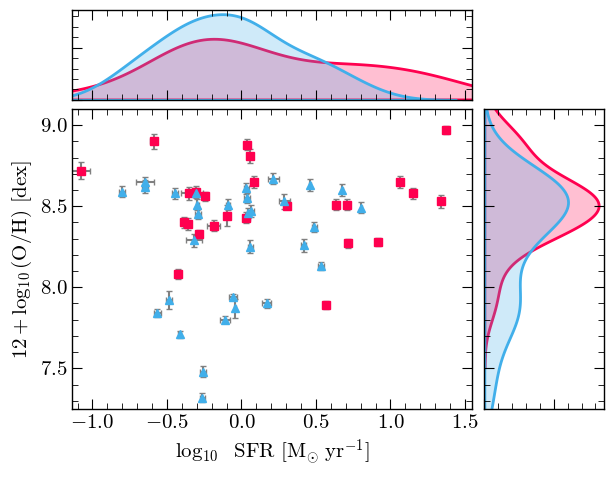

In [129]:
fig, ax = pf.create_plot()

ax2 = fig.add_axes((0,1.03,1,0.3), sharex=ax)
ax3 = fig.add_axes((1.03,0,0.3,1), sharey=ax)

for a in [ax2,ax3]:
    plt.setp(a.get_xticklabels(), visible=False)
    plt.setp(a.get_yticklabels(), visible=False)

axes = [ax,ax2,ax3,cbar]


for i,s in enumerate(selection):
    err = 0.432*sfrs_er[i]/sfrs[i]
    ax.errorbar(np.log10(sfrs[i]), mtable[i]['Z_dir_gen'],
                yerr = mtable[i]['Z_dir_gen_err'], xerr=err,
                fmt = m[i], color=c[i], ecolor='gray', capsize=2)
    
    sns.kdeplot(x = np.log10(sfrs[i]), ax =ax2, color=c[i], lw=2, fill=True)
    sns.kdeplot(y = mtable[i]['Z_dir_gen'], ax =ax3, color=c[i], lw=2, fill=True)

ax.set_ylim(7.25,9.1)
ax.set_xlim(-1.135,1.55)

ax.set_xlabel(r'$\log_{10}\;$ SFR [M$_{\odot}\;$yr$^{-1}$]')
ax.set_ylabel(r'$12+\log_{10}$(O/H) [dex]')

pf.fix_plot(axes)
fig.savefig(f'figs/sfr_met.png', dpi=600, bbox_inches='tight')

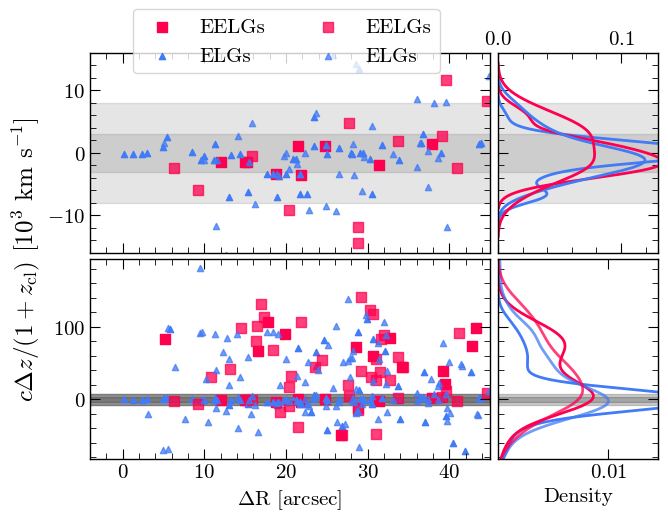

In [144]:
def getrecc(z):
    # return speedoflight.value * ((1+z)**2 - 1) / ((1+z)**2 + 1)
    c = speedoflight.value
    return (((1+z)**2 - 1) / ((1+z)**2 + 1))*c

fig, ax = pf.create_plot((4,2))
ax2 = fig.add_axes((1.02,0,0.4,1), sharey=ax)
plt.setp(ax2.get_yticklabels(), visible=False)


ax3 = fig.add_axes((0,1.03,1,1), sharex=ax)
plt.setp(ax3.get_xticklabels(), visible=False)
ax4 = fig.add_axes((1.02,1.03,0.4,1), sharey=ax3)
plt.setp(ax4.get_xticklabels(), visible=False)
plt.setp(ax4.get_yticklabels(), visible=False)



for i in range(2):
    t = tabs[i]
    s = selection[i]

    ##############
    eelgmask = np.isin(t['object_id'], s['object_id'])
    elgs = t[~eelgmask]

    ### just EELGs ###
    recv = getrecc(s['z'])
    clusv = getrecc(s['zcluster'])
    diff = (recv-clusv)/1e6
    metric = (speedoflight.value*(s['z']-s['zcluster']))/(1+s['zcluster'])/1e6

    # ### whole ELG population ###
    recv_all = getrecc(elgs['z'])
    clusv_all = getrecc(elgs['zcluster'])
    diff_all = (recv_all-clusv_all)/1e6
    metric_all = (speedoflight.value*(elgs['z']-elgs['zcluster']))/(1+elgs['zcluster'])/1e6

    #### PLOTS #####

    # ax2.hist(metric_all, orientation='horizontal', histtype='step', color="#427bf6", density=True, lw=4)
    # ax2.hist(metric, orientation='horizontal', histtype='step', color='#ff004f', density=True, lw=4)

    ax.scatter(s['angdisp'],metric, c='#ff004f', marker='s', s=50, alpha=(1-(i/4)))
    ax.scatter(elgs['angdisp'],metric_all, c='#427bf6', marker='^', s=20, alpha=1-(i/4))
    sns.kdeplot(y=metric_all,color="#427bf6", lw=2, ax=ax2, alpha=1-(i/4))
    sns.kdeplot(y=metric,color="#ff004f", lw=2, ax=ax2, alpha=1-(i/4))

    ax.set_xlim(-4,45)
    ax.set_ylim(-82, 194)

    ax2.set_xlim(0,0.0145)
    ax2.set_xticks([0.01])


    for j in [3,8]:
        for a in [ax,ax2]:
            a.fill_between([-100,200],-j,j,alpha=0.1, color='k', zorder=-10)

    # Shows the area from ax that ax3 contains
    ax.fill_between(ax.get_xlim(), -8, 8, color='grey', alpha=0.3, zorder=-11)

    ax.set_xlabel(r'$\Delta$R [arcsec]')
    # ax.set_ylabel(r'$c\Delta z / (1+z_{\mathrm{cl}})$ [$10^3$ km s$^{-1}$]')
    ax2.set_xlabel('Density')

    ax3.scatter(s['angdisp'],metric, c='#ff004f', marker='s', s=50, label='EELGs', alpha=1-(i/4))
    ax3.scatter(elgs['angdisp'],metric_all, c='#427bf6', marker='^', s=20, label='ELGs', alpha=1-(i/4))
    ### Second Plot ###



    # ax4.hist(metric_all, orientation='horizontal', histtype='step', color="#427bf6", density=True, lw=4, bins=np.linspace(-8,8,15))
    # ax4.hist(metric, orientation='horizontal', histtype='step', color='#ff004f', density=True, lw=4,bins=np.linspace(-8,8,10))

    mask1 = (metric_all>-8)&(metric_all<8)
    mask2 = (metric>-8)&(metric<8)

    sns.kdeplot(y=metric_all[mask1],color="#427bf6", lw=2, ax=ax4)
    sns.kdeplot(y=metric[mask2],color="#ff004f", lw=2, ax=ax4)

    ax3.set_ylim(-16,16)
    # ax3.set_ylim(-82, 194)

    ax4.set_xlim(0,0.13)
    # ax4.set_xticks([0.1,0.2])

fig.supylabel(r'$c\Delta z / (1+z_{\mathrm{cl}})$ [$10^3$ km s$^{-1}$]', position=(-.2,1))

for i in [3,8]:
    for a in [ax3,ax4]:
        pass
        a.fill_between([-100,200],-i,i,alpha=0.1, color='k', zorder=-10)

ax4.tick_params(labelbottom=False,labeltop=True)

fig.legend(bbox_to_anchor=(.9,2.3), ncol=2)

pf.fix_plot([ax,ax2,ax3,ax4])
fig.savefig(f'figs/environ.png', dpi=600, bbox_inches='tight')

In [139]:
t

[<Table length=146>
                object_id                ...  hei5876_vel_disp 
                  str40                  ...      float64      
 --------------------------------------- ... ------------------
 16d23m19pt35750823s-24d38m39pt98629732s ...  84.10827977000764
 16d23m11pt21592155s-24d39m07pt58635986s ...  52.72295261171051
 16d23m34pt54069919s-24d38m44pt18585516s ...  72.21548116261206
 16d23m25pt29930915s-24d39m00pt18617469s ...  64.54649010874104
 16d22m51pt19268571s-24d38m24pt38599595s ...  68.08873471346116
 16d23m41pt80164201s-24d38m36pt18549406s ...  58.15611881445357
 16d23m22pt87887854s-24d39m05pt98623242s ...  77.88628653003278
 16d23m13pt19641962s-24d39m05pt18635586s ... 38.030551419033046
 16d23m11pt43597948s-24d39m09pt38635975s ...  50.82010706310714
                                     ... ...                ...
 135d08m58pt72285054s20d54m01pt88874269s ... 36.714958684879434
 135d09m16pt70598875s20d53m56pt48859839s ...   61.3482931525792
  135d08m52pt9426708